In [2]:
import sys
import tensorflow as tf
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import seaborn
import cv2

print("Python       :", sys.version.split()[0])
print("TensorFlow   :", tf.__version__)
print("NumPy        :", np.__version__)
print("Pandas       :", pd.__version__)
print("Scikit-learn :", sklearn.__version__)
print("Matplotlib   :", matplotlib.__version__)
print("Seaborn      :", seaborn.__version__)
print("OpenCV       :", cv2.__version__)

Python       : 3.12.13
TensorFlow   : 2.20.0
NumPy        : 2.0.2
Pandas       : 2.3.3
Scikit-learn : 1.6.1
Matplotlib   : 3.10.0
Seaborn      : 0.13.2
OpenCV       : 4.13.0


In [3]:
import os, io, time, zipfile, urllib.request, random, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)
print("NumPy version:", np.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

BASE_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else "/content"
FIG_DIR = os.path.join(BASE_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)
DPI = 600

def savefig(name):
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, dpi=DPI, bbox_inches="tight")
    print("Saved:", path)


TensorFlow version: 2.20.0
Keras version: 3.13.2
NumPy version: 2.0.2
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [13]:
import os

if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)

print("Old corrupted ZIP removed.")

Old corrupted ZIP removed.


In [18]:
DATA_DIR = "/kaggle/input/datasets/miruthulajmm/har-dataset/UCI HAR Dataset/UCI HAR Dataset"
HAR_ROOT = DATA_DIR

TRAIN_DIR = os.path.join(HAR_ROOT, "train")
TEST_DIR = os.path.join(HAR_ROOT, "test")

print("Dataset ready.")
print("Train:", TRAIN_DIR)
print("Test:", TEST_DIR)
print("Train files:", len(os.listdir(os.path.join(TRAIN_DIR, "Inertial Signals"))))
print("Test files:", len(os.listdir(os.path.join(TEST_DIR, "Inertial Signals"))))

Dataset ready.
Train: /kaggle/input/datasets/miruthulajmm/har-dataset/UCI HAR Dataset/UCI HAR Dataset/train
Test: /kaggle/input/datasets/miruthulajmm/har-dataset/UCI HAR Dataset/UCI HAR Dataset/test
Train files: 9
Test files: 9


In [20]:
SIGNALS = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

ACTIVITY_NAMES = {
    1: "WALKING", 2: "WALKING_UPSTAIRS", 3: "WALKING_DOWNSTAIRS",
    4: "SITTING", 5: "STANDING", 6: "LAYING",
}

def load_signals(split):
    """Load raw inertial signals for a split ('train' or 'test') -> (N, 128, 9)."""
    base = os.path.join(HAR_ROOT, split, "Inertial Signals")
    channels = []
    for sig in SIGNALS:
        fpath = os.path.join(base, f"{sig}_{split}.txt")
        arr = np.loadtxt(fpath)              # (N, 128)
        channels.append(arr)
    X = np.stack(channels, axis=-1)          # (N, 128, 9)
    y = np.loadtxt(os.path.join(HAR_ROOT, split, f"y_{split}.txt")).astype(int)
    return X, y

X_train_full, y_train_full = load_signals("train")
X_test_full, y_test_full = load_signals("test")

print("Raw train tensor:", X_train_full.shape, " Raw test tensor:", X_test_full.shape)


Raw train tensor: (7352, 128, 9)  Raw test tensor: (2947, 128, 9)


In [22]:
X_train, y_train = X_train_full, y_train_full
X_test, y_test = X_test_full, y_test_full

y_train_enc = y_train - 1
y_test_enc = y_test - 1

print("Train:", X_train.shape, y_train_enc.shape)
print("Test :", X_test.shape, y_test_enc.shape)

Train: (7352, 128, 9) (7352,)
Test : (2947, 128, 9) (2947,)


In [23]:
# Normalize 
mu = X_train.mean(axis=(0, 1), keepdims=True)
sigma = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train_n = (X_train - mu) / sigma
X_val_n = (X_val - mu) / sigma
X_test_n = (X_test - mu) / sigma

print("=== Expected Preprocessing Output ===")
print("Input tensor shape:")
print(f"  Training   : {X_train_n.shape}")
print(f"  Validation : {X_val_n.shape}")
print(f"  Testing    : {X_test_n.shape}")
print(f"Number of classes: {len(ACTIVITY_NAMES)}")
print(f"Number of features per time step: {X_train_n.shape[2]}")
print(f"Sequence length: {X_train_n.shape[1]}")

print("\nClass distribution (train):")
print(pd.Series(y_train).map(ACTIVITY_NAMES).value_counts())


=== Expected Preprocessing Output ===
Input tensor shape:
  Training   : (7352, 128, 9)
  Validation : (495, 128, 9)
  Testing    : (2947, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128

Class distribution (train):
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


## 2. Temporal Data Visualization (Plot 1)

Sensor signal vs. time for at least three channels, across at least three activity classes.

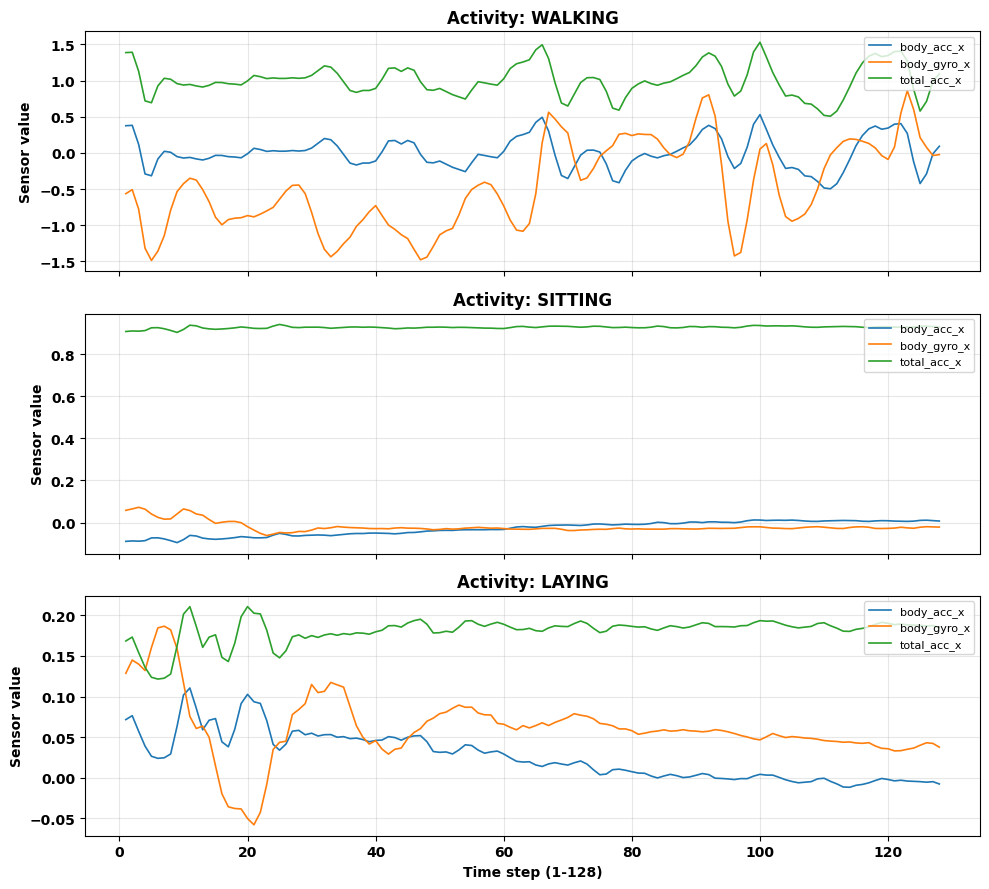

In [24]:
#Temporal Data Visualization
def first_index_of_class(y, class_id):
    return np.where(y == class_id)[0][0]


classes_to_plot = [1, 4, 6]
channels_to_plot = [0, 3, 6]
channel_labels = ["body_acc_x", "body_gyro_x", "total_acc_x"]

fig, axes = plt.subplots(
    len(classes_to_plot), 1,
    figsize=(10, 9),
    sharex=True
)

t = np.arange(1, 129)

for ax, c in zip(axes, classes_to_plot):
    idx = first_index_of_class(y_train, c)

    for ch, lbl in zip(channels_to_plot, channel_labels):
        ax.plot(
            t,
            X_train[idx, :, ch],
            label=lbl,
            linewidth=1.2
        )

    # BOLD X/Y axes
    ax.set_ylabel(
        "Sensor value",
        fontweight="bold"
    )

    # BOLD X and Y tick labels
    ax.tick_params(axis="both", labelsize=10)

    for label in ax.get_xticklabels():
        label.set_fontweight("bold")

    for label in ax.get_yticklabels():
        label.set_fontweight("bold")

    ax.legend(loc="upper right", fontsize=8)
    ax.set_title(f"Activity: {ACTIVITY_NAMES[c]}", fontweight="bold")
    ax.grid(alpha=0.3)

# BOLD X-axis label
axes[-1].set_xlabel(
    "Time step (1-128)",
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("plot1_temporal_signals.png", dpi=600, bbox_inches="tight")
plt.show()

In [25]:
#Vanilla RNN
def rnn_step(x, h_prev, Wx=0.5, Wh=0.8, b=0.1):
    return np.tanh(Wx * x + Wh * h_prev + b)

x_seq = [0.5, 0.7, 0.2]
h = 0.0
print("Manual BPTT numerical exercise (Section 8):")
for i, x in enumerate(x_seq, start=1):
    h = rnn_step(x, h)
    print(f"  h{i} = tanh(0.5*{x} + 0.8*h{i-1} + 0.1) = {h:.6f}")


Manual BPTT numerical exercise (Section 8):
  h1 = tanh(0.5*0.5 + 0.8*h0 + 0.1) = 0.336376
  h2 = tanh(0.5*0.7 + 0.8*h1 + 0.1) = 0.616352
  h3 = tanh(0.5*0.2 + 0.8*h2 + 0.1) = 0.599958


In [27]:
#Model definitions
INPUT_SHAPE = (X_train_n.shape[1], X_train_n.shape[2])   # (128, 9)
NUM_CLASSES = len(ACTIVITY_NAMES)
RECURRENT_UNITS = 32
DROPOUT = 0.2
EPOCHS = 30
BATCH_SIZE = 32
LR = 1e-3

def build_model(recurrent_type="SimpleRNN", units=RECURRENT_UNITS, input_shape=INPUT_SHAPE):
    inputs = keras.Input(shape=input_shape)
    if recurrent_type == "SimpleRNN":
        x = layers.SimpleRNN(units)(inputs)
    elif recurrent_type == "LSTM":
        x = layers.LSTM(units)(inputs)
    elif recurrent_type == "GRU":
        x = layers.GRU(units)(inputs)
    else:
        raise ValueError(recurrent_type)
    x = layers.Dropout(DROPOUT)(x)
    x = layers.Dense(16, activation="relu")(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name=f"{recurrent_type}_classifier")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=LR),
                   loss="sparse_categorical_crossentropy",
                   metrics=["accuracy"])
    return model

build_model("SimpleRNN").summary()


Model: "SimpleRNN_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
#Train RNN, LSTM and GRU
def train_model(recurrent_type, X_tr, y_tr, X_va, y_va, epochs=EPOCHS, verbose=0):
    tf.random.set_seed(SEED)
    model = build_model(recurrent_type, input_shape=(X_tr.shape[1], X_tr.shape[2]))
    es = callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
    start = time.time()
    history = model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                         epochs=epochs, batch_size=BATCH_SIZE,
                         callbacks=[es], verbose=verbose)
    train_time = time.time() - start
    n_params = model.count_params()
    return model, history, train_time, n_params

results = {}
histories = {}

for m_type in ["SimpleRNN", "LSTM", "GRU"]:
    print(f"\n{'='*60}\nTraining {m_type} ...\n{'='*60}")
    model, hist, ttime, nparams = train_model(m_type, X_train_n, y_train_enc, X_val_n, y_val_enc, verbose=1)
    results[m_type] = {"model": model, "train_time": ttime, "params": nparams}
    histories[m_type] = hist
    print(f"{m_type}: params={nparams}, training_time={ttime:.2f}s, "
          f"best_val_acc={max(hist.history['val_accuracy']):.4f}")



Training SimpleRNN ...
Epoch 1/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.5798 - loss: 1.0718 - val_accuracy: 0.6444 - val_loss: 0.7799
Epoch 2/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6230 - loss: 0.9438 - val_accuracy: 0.6566 - val_loss: 0.8197
Epoch 3/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7097 - loss: 0.7201 - val_accuracy: 0.7091 - val_loss: 0.7095
Epoch 4/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7410 - loss: 0.6331 - val_accuracy: 0.7374 - val_loss: 0.6281
Epoch 5/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7685 - loss: 0.5689 - val_accuracy: 0.7657 - val_loss: 0.5696
Epoch 6/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7248 - loss: 0.6751 - val_accuracy: 0.7313 - val_loss: 0.6132
Epoch 7/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7554 - loss: 0.5795 - val_accuracy: 0.7636 - val_loss: 0.5646
Epoch 8/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7594 -

Saved: /kaggle/working/figures/plot2_training_validation_loss.png


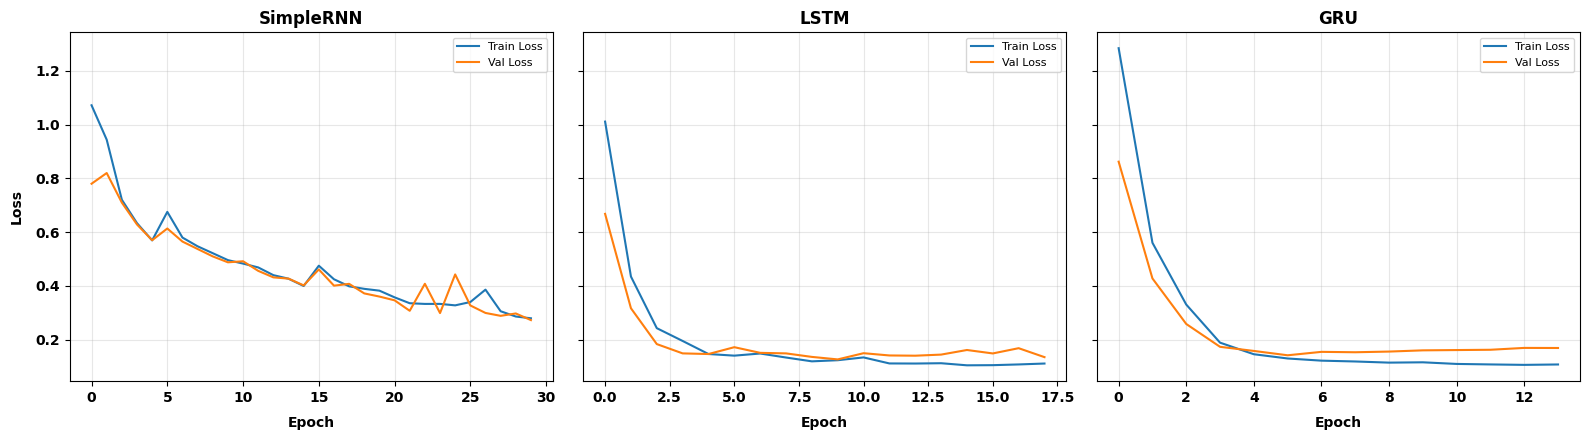

Saved: /kaggle/working/figures/plot3_training_validation_accuracy.png


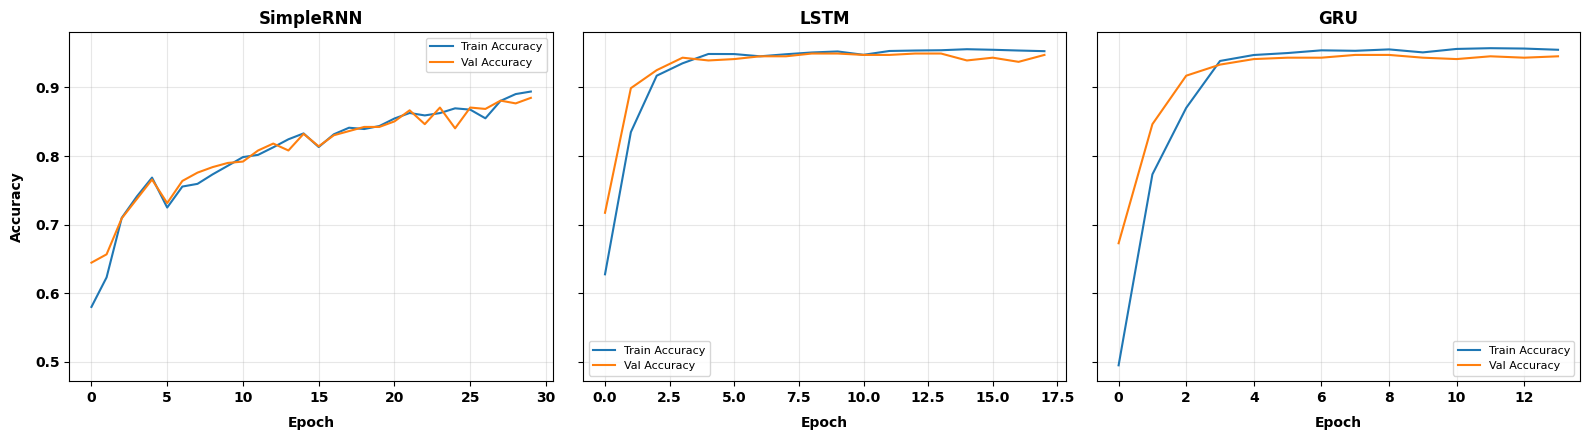

In [30]:
def plot_history(histories_dict, metric, ylabel, fname):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

    for ax, (name, hist) in zip(axes, histories_dict.items()):
        h = hist.history

        ax.plot(h[metric], label=f"Train {ylabel}")
        ax.plot(h[f"val_{metric}"], label=f"Val {ylabel}")

        ax.set_title(name, fontweight="bold")
        ax.set_xlabel("Epoch", fontweight="bold", labelpad=8)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

        # Bold X and Y tick labels
        ax.tick_params(axis="both", labelsize=10)

        for label in ax.get_xticklabels():
            label.set_fontweight("bold")

        for label in ax.get_yticklabels():
            label.set_fontweight("bold")

    # Bold Y-axis label
    axes[0].set_ylabel(ylabel, fontweight="bold", labelpad=8)

    plt.tight_layout()
    savefig(fname)
    plt.show()


plot_history(
    histories,
    "loss",
    "Loss",
    "plot2_training_validation_loss.png"
)

plot_history(
    histories,
    "accuracy",
    "Accuracy",
    "plot3_training_validation_accuracy.png"
)

In [31]:
#Performance evaluation
def evaluate_model(model, X_te, y_te_enc):
    y_prob = model.predict(X_te, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    acc = accuracy_score(y_te_enc, y_pred)
    prec = precision_score(y_te_enc, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_te_enc, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_te_enc, y_pred, average="macro", zero_division=0)
    cm = confusion_matrix(y_te_enc, y_pred)
    return dict(accuracy=acc, precision=prec, recall=rec, f1=f1, cm=cm, y_pred=y_pred)

eval_results = {}
for m_type in ["SimpleRNN", "LSTM", "GRU"]:
    ev = evaluate_model(results[m_type]["model"], X_test_n, y_test_enc)
    eval_results[m_type] = ev
    print(f"{m_type}: Acc={ev['accuracy']*100:.2f}%  "
          f"MacroP={ev['precision']*100:.2f}%  MacroR={ev['recall']*100:.2f}%  "
          f"MacroF1={ev['f1']*100:.2f}%")

summary_table = pd.DataFrame({
    m: {
        "Accuracy (%)": eval_results[m]["accuracy"] * 100,
        "Macro Precision (%)": eval_results[m]["precision"] * 100,
        "Macro Recall (%)": eval_results[m]["recall"] * 100,
        "Macro F1 (%)": eval_results[m]["f1"] * 100,
        "Parameters": results[m]["params"],
        "Training Time (s)": results[m]["train_time"],
    } for m in ["SimpleRNN", "LSTM", "GRU"]
}).T
summary_table.index.name = "Model"
summary_table


SimpleRNN: Acc=82.08%  MacroP=82.52%  MacroR=82.17%  MacroF1=82.10%
LSTM: Acc=90.19%  MacroP=90.28%  MacroR=90.44%  MacroF1=90.30%
GRU: Acc=89.79%  MacroP=89.71%  MacroR=89.95%  MacroF1=89.81%


,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
Model,,,,,,
SimpleRNN,82.083475,82.521838,82.168977,82.098839,1974.0,73.651384
LSTM,90.193417,90.278061,90.442122,90.297619,6006.0,42.832999
GRU,89.786223,89.714373,89.946903,89.810300,4758.0,31.439569


Saved: /kaggle/working/figures/plot4_confusion_matrices.png


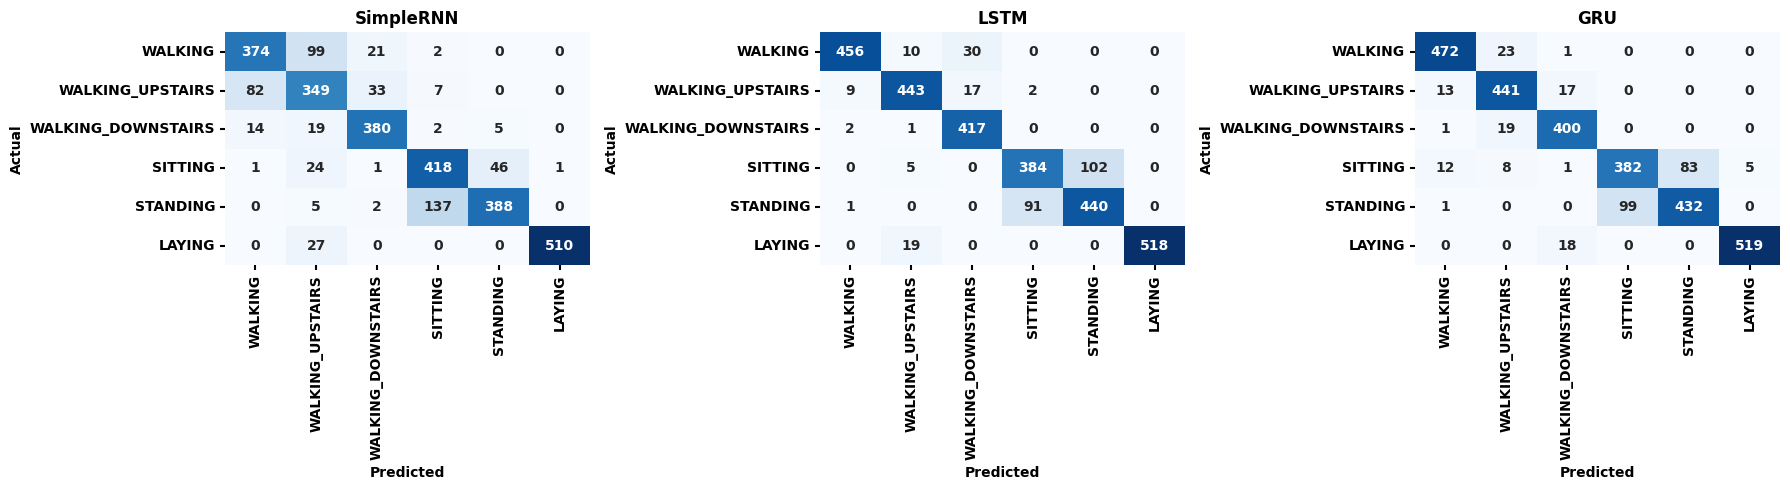

SimpleRNN: highest recognition = LAYING (95.0%), lowest = STANDING (72.9%)
LSTM: highest recognition = WALKING_DOWNSTAIRS (99.3%), lowest = SITTING (78.2%)
GRU: highest recognition = LAYING (96.6%), lowest = SITTING (77.8%)


In [32]:
#Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

labels_sorted = [ACTIVITY_NAMES[i+1] for i in range(NUM_CLASSES)]

for ax, m_type in zip(axes, ["SimpleRNN", "LSTM", "GRU"]):
    cm = eval_results[m_type]["cm"]

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=labels_sorted,
        yticklabels=labels_sorted,
        cbar=False,
        annot_kws={"fontweight": "bold"}
    )

    ax.set_title(m_type, fontweight="bold")
    ax.set_xlabel("Predicted", fontweight="bold")
    ax.set_ylabel("Actual", fontweight="bold")

    ax.tick_params(axis="x", rotation=90, width=1.5)
    ax.tick_params(axis="y", rotation=0, width=1.5)

    # Bold X/Y tick labels
    for label in ax.get_xticklabels():
        label.set_fontweight("bold")

    for label in ax.get_yticklabels():
        label.set_fontweight("bold")


plt.tight_layout()
savefig("plot4_confusion_matrices.png")
plt.show()


for m_type in ["SimpleRNN", "LSTM", "GRU"]:
    cm = eval_results[m_type]["cm"]
    per_class_acc = cm.diagonal() / cm.sum(axis=1)

    best = labels_sorted[np.argmax(per_class_acc)]
    worst = labels_sorted[np.argmin(per_class_acc)]

    print(
        f"{m_type}: highest recognition = {best} "
        f"({per_class_acc.max()*100:.1f}%), "
        f"lowest = {worst} "
        f"({per_class_acc.min()*100:.1f}%)"
    )

In [33]:
#RNN vs LSTM vs GRU
structural = pd.DataFrame({
    "RNN":  ["Yes","No","No","No","No","No","No"],
    "LSTM": ["Yes","Yes","Yes","Yes","Yes","No","No"],
    "GRU":  ["Yes","No","No","No","No","Yes","Yes"],
}, index=["Hidden state","Cell state","Forget gate","Input gate",
          "Output gate","Update gate","Reset gate"])

empirical = pd.DataFrame({
    m: {
        "Parameters": results[m]["params"],
        "Training time (s)": round(results[m]["train_time"], 2),
        "Test F1-score (%)": round(eval_results[m]["f1"] * 100, 2),
    } for m in ["SimpleRNN", "LSTM", "GRU"]
}).T

print("Structural comparison:")
display(structural)
print("\nEmpirical comparison:")
display(empirical)


Structural comparison:


,RNN,LSTM,GRU
Hidden state,Yes,Yes,Yes
Cell state,No,Yes,No
Forget gate,No,Yes,No
Input gate,No,Yes,No
Output gate,No,Yes,No
Update gate,No,No,Yes
Reset gate,No,No,Yes



Empirical comparison:


,Parameters,Training time (s),Test F1-score (%)
SimpleRNN,1974.0,73.65,82.10
LSTM,6006.0,42.83,90.30
GRU,4758.0,31.44,89.81


Saved: /kaggle/working/figures/plot5_model_performance_comparison.png


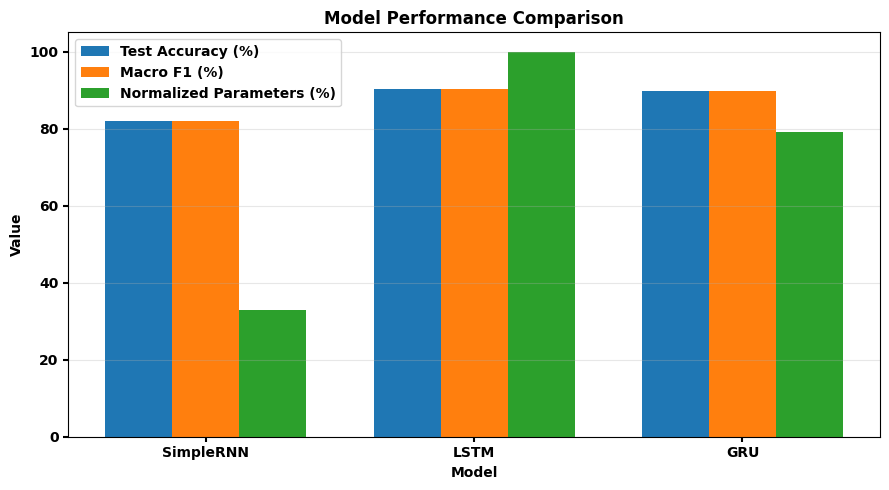

In [34]:
# Plot 5: Model Performance Comparison

fig, ax = plt.subplots(figsize=(9, 5))

model_names = ["SimpleRNN", "LSTM", "GRU"]

acc_vals = [eval_results[m]["accuracy"] * 100 for m in model_names]
f1_vals = [eval_results[m]["f1"] * 100 for m in model_names]
param_norm = [
    results[m]["params"] / max(results[mm]["params"] for mm in model_names) * 100
    for m in model_names
]

x = np.arange(len(model_names))
width = 0.25

ax.bar(x - width, acc_vals, width, label="Test Accuracy (%)")
ax.bar(x, f1_vals, width, label="Macro F1 (%)")
ax.bar(x + width, param_norm, width, label="Normalized Parameters (%)")

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontweight="bold")
ax.set_xlabel("Model", fontweight="bold")

ax.set_ylabel("Value", fontweight="bold")
ax.set_title("Model Performance Comparison", fontweight="bold")

# Bold Y-axis tick labels
for label in ax.get_yticklabels():
    label.set_fontweight("bold")

# Bold X-axis tick labels
for label in ax.get_xticklabels():
    label.set_fontweight("bold")

# Bold legend text
legend = ax.legend()
for text in legend.get_texts():
    text.set_fontweight("bold")

ax.tick_params(axis="both", width=1.5)
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
savefig("plot5_model_performance_comparison.png")
plt.show()

In [35]:
#Effect of sequence length (T=32,64,128)
def truncate_seq(X, T):
    return X[:, -T:, :]   # keep the last T time steps

seq_lengths = [32, 64, 128]
seqlen_results = {m: {} for m in ["SimpleRNN", "LSTM", "GRU"]}

for T in seq_lengths:
    Xtr_T = truncate_seq(X_train_n, T)
    Xva_T = truncate_seq(X_val_n, T)
    Xte_T = truncate_seq(X_test_n, T)
    print(f"\n--- Sequence length T={T} ---")
    for m_type in ["SimpleRNN", "LSTM", "GRU"]:
        model, hist, ttime, nparams = train_model(m_type, Xtr_T, y_train_enc, Xva_T, y_val_enc,
                                                    epochs=20, verbose=0)
        ev = evaluate_model(model, Xte_T, y_test_enc)
        seqlen_results[m_type][T] = ev["f1"]
        print(f"  {m_type}: F1={ev['f1']*100:.2f}%")

seqlen_table = pd.DataFrame(seqlen_results).T
seqlen_table.columns = [f"T={t}" for t in seq_lengths]
seqlen_table



--- Sequence length T=32 ---
  SimpleRNN: F1=84.21%
  LSTM: F1=88.43%
  GRU: F1=89.20%

--- Sequence length T=64 ---
  SimpleRNN: F1=78.48%
  LSTM: F1=88.72%
  GRU: F1=90.44%

--- Sequence length T=128 ---
  SimpleRNN: F1=74.86%
  LSTM: F1=89.07%
  GRU: F1=90.68%


,T=32,T=64,T=128
SimpleRNN,0.842083,0.784759,0.748590
LSTM,0.884317,0.887217,0.890697
GRU,0.891991,0.904445,0.906811


Saved: /kaggle/working/figures/plot6_sequence_length_vs_f1.png


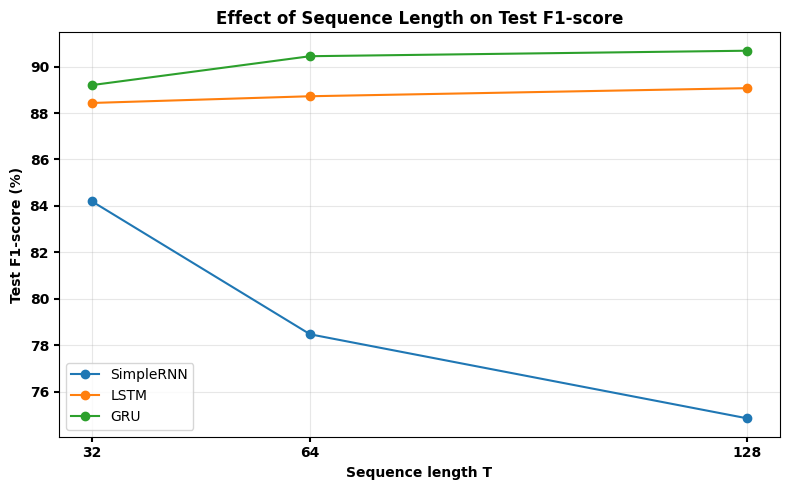

In [36]:
# Plot 6: Sequence Length vs Test F1-score
fig, ax = plt.subplots(figsize=(8, 5))

for m_type in ["SimpleRNN", "LSTM", "GRU"]:
    f1s = [seqlen_results[m_type][T] * 100 for T in seq_lengths]
    ax.plot(seq_lengths, f1s, marker="o", label=m_type)

ax.set_xlabel("Sequence length T", fontweight="bold")
ax.set_ylabel("Test F1-score (%)", fontweight="bold")
ax.set_title("Effect of Sequence Length on Test F1-score", fontweight="bold")
ax.set_xticks(seq_lengths)

ax.tick_params(axis="x", labelsize=10, width=1.5)
ax.tick_params(axis="y", labelsize=10, width=1.5)

for label in ax.get_xticklabels():
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
savefig("plot6_sequence_length_vs_f1.png")
plt.show()

In [37]:
#Video Understanding
import os
import kagglehub

# Get Kaggle API token from Kaggle Secrets
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
os.environ["KAGGLE_API_TOKEN"] = user_secrets.get_secret("KAGGLE_API_TOKEN")

# Download the REAL UCF101 dataset
UCF_DIR = kagglehub.dataset_download(
    "pevogam/ucf101",
    output_dir="/kaggle/working/ucf101"
)

print("UCF101 downloaded to:")
print(UCF_DIR)

print("\nTop-level contents:")
print(os.listdir(UCF_DIR)[:20])

UCF101 downloaded to:
/kaggle/input/datasets/pevogam/ucf101

Top-level contents:
['UCF101', 'UCF101TrainTestSplits-RecognitionTask']


In [47]:
ACTION_CLASSES = ["Basketball","Biking","CricketBowling","TennisSwing","WalkingWithDog"]
N_FRAMES = 10
FRAME_SIZE = 224
VIDEOS_PER_CLASS = 25

video_frames_all, video_labels_all, video_paths_all = [], [], []

def sample_frames_from_video(path):
    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if not cap.isOpened() or total < 1:
        cap.release()
        return None
    frames = []
    for i in np.linspace(0,total-1,N_FRAMES).astype(int):
        cap.set(cv2.CAP_PROP_POS_FRAMES,int(i))
        ok,frame = cap.read()
        if not ok:
            cap.release()
            return None
        frame = cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)
        frames.append(cv2.resize(frame,(FRAME_SIZE,FRAME_SIZE)))
    cap.release()
    return np.stack(frames).astype(np.uint8)

class_dirs = {}
for root in [UCF_DIR,"/kaggle/input","/kaggle/working"]:
    if os.path.exists(root):
        for r,ds,_ in os.walk(root):
            for d in ds:
                if d.lower() in [x.lower() for x in ACTION_CLASSES]:
                    class_dirs[d.lower()] = os.path.join(r,d)

for label,cls in enumerate(ACTION_CLASSES):
    class_dir = class_dirs[cls.lower()]
    files = sorted([os.path.join(class_dir,f) for f in os.listdir(class_dir) if f.lower().endswith((".avi",".mp4",".mov",".mkv"))])[:VIDEOS_PER_CLASS]
    print(cls,len(files))
    for path in files:
        frames = sample_frames_from_video(path)
        if frames is not None:
            video_frames_all.append(frames)
            video_labels_all.append(label)
            video_paths_all.append(path)

video_frames_all = np.stack(video_frames_all)
video_labels_all = np.array(video_labels_all)

print("Video tensor:",video_frames_all.shape)
print("Labels:",video_labels_all.shape)

Basketball 25
Biking 25
CricketBowling 25
TennisSwing 25
WalkingWithDog 25
Video tensor: (125, 10, 224, 224, 3)
Labels: (125,)


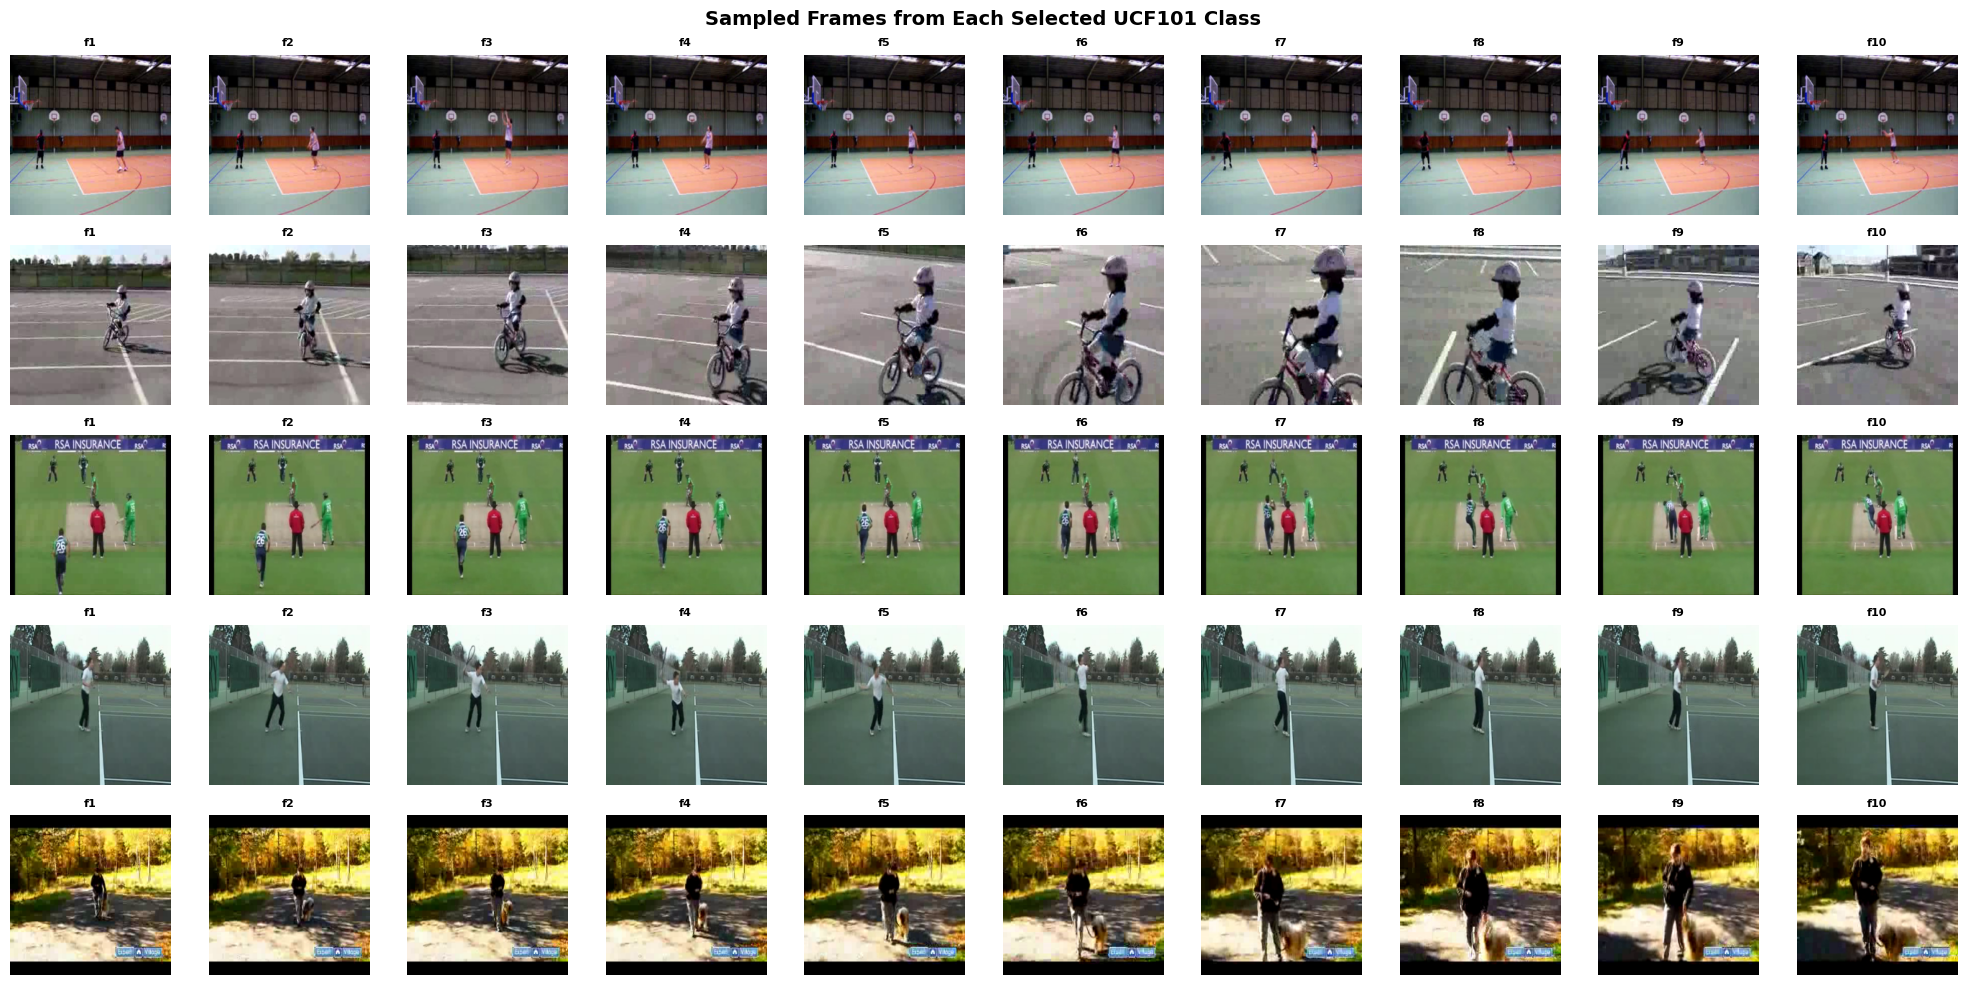

In [39]:
fig, axes = plt.subplots(len(ACTION_CLASSES), N_FRAMES, figsize=(20, 10))

for r, cls in enumerate(ACTION_CLASSES):
    idx = np.where(video_labels_all == r)[0][0]
    for i in range(N_FRAMES):
        axes[r, i].imshow(video_frames_all[idx, i])
        axes[r, i].axis("off")
        axes[r, i].set_title(f"f{i+1}", fontsize=8, fontweight="bold")
    axes[r, 0].set_ylabel(cls, fontsize=10, fontweight="bold")

fig.suptitle("Sampled Frames from Each Selected UCF101 Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/plot7_video_sample_frames_all_classes.png", dpi=300, bbox_inches="tight")
plt.show()

### 11.1 CNN Feature Extraction (Frozen MobileNetV2)

In [48]:
import tensorflow as tf

mobilenet = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet",
    pooling="avg"
)

mobilenet.trainable = False

print("MobileNetV2 loaded")
print("CNN feature dimension D =", mobilenet.output_shape[-1])

MobileNetV2 loaded
CNN feature dimension D = 1280


In [50]:
FEATURE_DIM = mobilenet.output_shape[-1]
print("CNN feature dimension D =", FEATURE_DIM)

def extract_features(video_batch, cnn, batch_size=16):
    B,T,H,W,C = video_batch.shape
    flat = video_batch.reshape(B*T,H,W,C).astype("float32")
    flat = tf.keras.applications.mobilenet_v2.preprocess_input(flat)
    feats = cnn.predict(flat, batch_size=batch_size, verbose=1)
    return feats.reshape(B,T,-1)

video_features = extract_features(video_frames_all, mobilenet)
print("Resulting tensor supplied to the recurrent network:", video_features.shape)

CNN feature dimension D = 1280
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Resulting tensor supplied to the recurrent network: (125, 10, 1280)


In [51]:
Xv_train, Xv_temp, yv_train, yv_temp = train_test_split(
    video_features, video_labels_all, test_size=0.30, random_state=SEED, stratify=video_labels_all)
Xv_val, Xv_test, yv_val, yv_test = train_test_split(
    Xv_temp, yv_temp, test_size=0.50, random_state=SEED, stratify=yv_temp)

print("Video train/val/test:", Xv_train.shape, Xv_val.shape, Xv_test.shape)


Video train/val/test: (87, 10, 1280) (19, 10, 1280) (19, 10, 1280)


In [53]:
#CNN-LSTM / CNN-GRU
def build_video_model(recurrent_type="LSTM", units=32, feat_dim=FEATURE_DIM, n_classes=len(ACTION_CLASSES)):
    inputs = keras.Input(shape=(N_FRAMES, feat_dim))
    if recurrent_type == "LSTM":
        x = layers.LSTM(units)(inputs)
    else:
        x = layers.GRU(units)(inputs)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name=f"CNN_{recurrent_type}_video")
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                   loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

VIDEO_RECURRENT = "LSTM"   # switch to "GRU" to compare (Additional Exercise 6)
video_model = build_video_model(VIDEO_RECURRENT)
es = callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)

video_history = video_model.fit(
    Xv_train, yv_train, validation_data=(Xv_val, yv_val),
    epochs=25, batch_size=8, callbacks=[es], verbose=1)


Epoch 1/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.3793 - loss: 1.5083 - val_accuracy: 0.7368 - val_loss: 1.1757
Epoch 2/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8736 - loss: 0.7579 - val_accuracy: 0.9474 - val_loss: 0.5830
Epoch 3/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9310 - loss: 0.4367 - val_accuracy: 0.9474 - val_loss: 0.3386
Epoch 4/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9655 - loss: 0.2562 - val_accuracy: 0.9474 - val_loss: 0.3039
Epoch 5/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9655 - loss: 0.2126 - val_accuracy: 1.0000 - val_loss: 0.1794
Epoch 6/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9770 - loss: 0.1668 - val_accuracy: 0.9474 - val_loss: 0.1817
Epoch 7/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.1153 - val_accuracy: 1.0000 - val_loss: 0.1031
Epoch 8/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9885 - loss: 0.0972 - val_accuracy: 1.0000 - v

Saved: /kaggle/working/figures/plot8_video_training_validation_curves.png


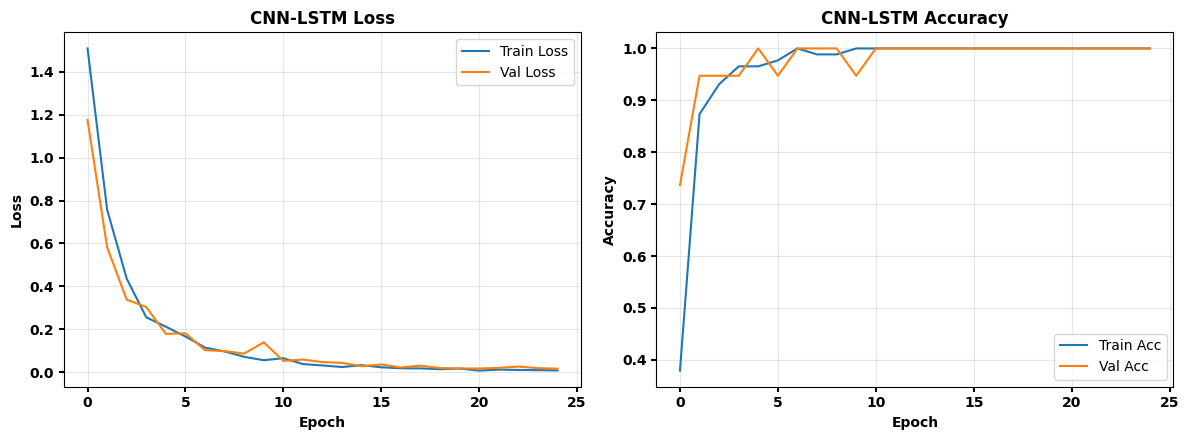

In [54]:
# Plot 8: Video Training and Validation Curves

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
h = video_history.history

axes[0].plot(h["loss"], label="Train Loss")
axes[0].plot(h["val_loss"], label="Val Loss")
axes[0].set_title(f"CNN-{VIDEO_RECURRENT} Loss", fontweight="bold")
axes[0].set_xlabel("Epoch", fontweight="bold")
axes[0].set_ylabel("Loss", fontweight="bold")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(h["accuracy"], label="Train Acc")
axes[1].plot(h["val_accuracy"], label="Val Acc")
axes[1].set_title(f"CNN-{VIDEO_RECURRENT} Accuracy", fontweight="bold")
axes[1].set_xlabel("Epoch", fontweight="bold")
axes[1].set_ylabel("Accuracy", fontweight="bold")

for ax in axes:
    ax.tick_params(axis="both", width=1.5)
axes[1].legend()
axes[1].grid(alpha=0.3)

for ax in axes:
    for label in ax.get_xticklabels():
        label.set_fontweight("bold")
    for label in ax.get_yticklabels():
        label.set_fontweight("bold")

plt.tight_layout()
savefig("plot8_video_training_validation_curves.png")
plt.show()

Saved: /kaggle/working/figures/plot9_video_confusion_matrix.png


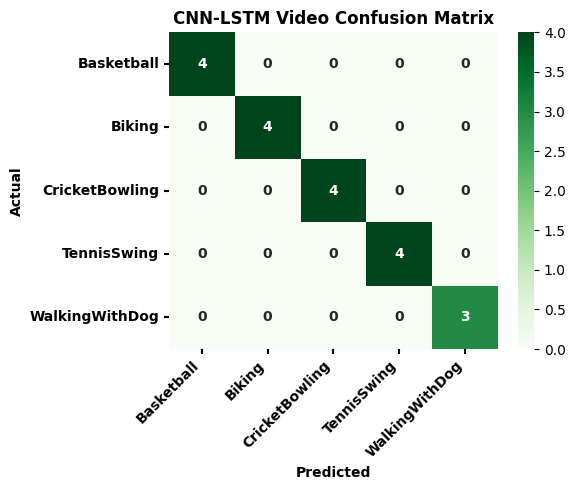

Predicted class : CricketBowling
Actual class    : CricketBowling
Confidence      : 1.00

Video model – Acc=100.00% F1=100.00% Params=168229


In [55]:
# Plot 9: Video Confusion Matrix + sample prediction

yv_prob = video_model.predict(Xv_test, verbose=0)
yv_pred = np.argmax(yv_prob, axis=1)
cm_video = confusion_matrix(yv_test, yv_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_video,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=ACTION_CLASSES,
    yticklabels=ACTION_CLASSES,
    ax=ax,
    annot_kws={"fontweight": "bold"}
)

ax.set_xlabel("Predicted", fontweight="bold")
ax.set_ylabel("Actual", fontweight="bold")
ax.set_title(
    f"CNN-{VIDEO_RECURRENT} Video Confusion Matrix",
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right", fontweight="bold")
plt.tick_params(axis="both", width=1.5)
plt.yticks(rotation=0, fontweight="bold")

plt.tight_layout()
savefig("plot9_video_confusion_matrix.png")
plt.show()

sample_idx = 0
pred_class = ACTION_CLASSES[yv_pred[sample_idx]]
actual_class = ACTION_CLASSES[yv_test[sample_idx]]
confidence = yv_prob[sample_idx, yv_pred[sample_idx]]

print(f"Predicted class : {pred_class}")
print(f"Actual class    : {actual_class}")
print(f"Confidence      : {confidence:.2f}")

video_acc = accuracy_score(yv_test, yv_pred)
video_f1 = f1_score(yv_test, yv_pred, average="macro", zero_division=0)
video_prec = precision_score(yv_test, yv_pred, average="macro", zero_division=0)
video_rec = recall_score(yv_test, yv_pred, average="macro", zero_division=0)
video_params = video_model.count_params()

print(f"\nVideo model – Acc={video_acc*100:.2f}% F1={video_f1*100:.2f}% Params={video_params}")

In [57]:
#Sequence to sequence learning (Encoder-decoder LSTM) - Reversal Task
VOCAB_MIN, VOCAB_MAX = 0, 9         # digits 0-9
SEQ2SEQ_LEN = 4
NUM_SEQUENCES = 6000
PAD_TOKEN = 10
START_TOKEN = 11
VOCAB_SIZE = 12                     # digits 0-9 + PAD + START

rng = np.random.RandomState(SEED)

def gen_seq2seq_data(n, length=SEQ2SEQ_LEN):
    X = rng.randint(VOCAB_MIN, VOCAB_MAX + 1, size=(n, length))
    Y = X[:, ::-1].copy()
    return X, Y

X_s2s, Y_s2s = gen_seq2seq_data(NUM_SEQUENCES)

# Decoder input: [START, y1, y2, y3] ; Decoder target: [y1, y2, y3, y4]
decoder_input = np.concatenate([np.full((NUM_SEQUENCES, 1), START_TOKEN), Y_s2s[:, :-1]], axis=1)
decoder_target = Y_s2s

Xtr_s2s, Xte_s2s, dec_in_tr, dec_in_te, dec_tgt_tr, dec_tgt_te = train_test_split(
    X_s2s, decoder_input, decoder_target, test_size=0.2, random_state=SEED)

print("Encoder input train:", Xtr_s2s.shape, " Decoder input train:", dec_in_tr.shape)


Encoder input train: (4800, 4)  Decoder input train: (4800, 4)


In [58]:
EMBED_DIM = 16
S2S_UNITS = 64

# --- Encoder ---
encoder_inputs = keras.Input(shape=(SEQ2SEQ_LEN,), name="encoder_input")
enc_emb = layers.Embedding(VOCAB_SIZE, EMBED_DIM)(encoder_inputs)
_, state_h, state_c = layers.LSTM(S2S_UNITS, return_state=True)(enc_emb)
encoder_states = [state_h, state_c]

# --- Decoder ---
decoder_inputs = keras.Input(shape=(SEQ2SEQ_LEN,), name="decoder_input")
dec_emb_layer = layers.Embedding(VOCAB_SIZE, EMBED_DIM)
dec_emb = dec_emb_layer(decoder_inputs)
decoder_lstm = layers.LSTM(S2S_UNITS, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)
decoder_dense = layers.Dense(VOCAB_SIZE, activation="softmax")
decoder_outputs = decoder_dense(decoder_outputs)

seq2seq_model = keras.Model([encoder_inputs, decoder_inputs], decoder_outputs, name="seq2seq_encoder_decoder")
seq2seq_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                       loss="sparse_categorical_crossentropy", metrics=["accuracy"])
seq2seq_model.summary()


Model: "seq2seq_encoder_decoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 4, 16)     │        192 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 4, 16)     │        192 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ [(None, 64),      │     20,736 │ embedding[0][0]   │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ [(None, 4, 64),   │     20,736 │ embedding_1[0][0… │
│                     │ (None, 64),       │            │ lstm_6[0][1],     │
│                     │ (None, 64)]       │            │ lstm_6[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 4, 12)     │        780 │ lstm_7[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 42,636 (166.55 KB)

 Trainable params: 42,636 (166.55 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
latent_dim = 64
vocab_size = 10
seq_len = Xtr_s2s.shape[1]

enc_in = tf.keras.Input(shape=(seq_len,))
enc_emb = tf.keras.layers.Embedding(vocab_size, latent_dim)(enc_in)
_, enc_h, enc_c = tf.keras.layers.LSTM(latent_dim, return_state=True)(enc_emb)

dec_in = tf.keras.Input(shape=(seq_len,))
dec_emb = tf.keras.layers.Embedding(vocab_size, latent_dim)(dec_in)
dec_out = tf.keras.layers.LSTM(latent_dim, return_sequences=True)(dec_emb, initial_state=[enc_h, enc_c])
dec_out = tf.keras.layers.Dense(vocab_size, activation="softmax")(dec_out)

seq2seq_model = tf.keras.Model([enc_in, dec_in], dec_out)
seq2seq_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

seq2seq_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19      │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_20      │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 4, 64)     │        640 │ input_layer_19[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 4, 64)     │        640 │ input_layer_20[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_8 (LSTM)       │ [(None, 64),      │     33,024 │ embedding_2[0][0] │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_9 (LSTM)       │ (None, 4, 64)     │     33,024 │ embedding_3[0][0… │
│                     │                   │            │ lstm_8[0][1],     │
│                     │                   │            │ lstm_8[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 4, 10)     │        650 │ lstm_9[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 67,978 (265.54 KB)

 Trainable params: 67,978 (265.54 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
s2s_history = seq2seq_model.fit(
    [Xtr_s2s, dec_in_tr], dec_tgt_tr,
    validation_data=([Xte_s2s, dec_in_te], dec_tgt_te),
    epochs=40, batch_size=64, verbose=1,
    callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)])


Epoch 1/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.3555 - loss: 1.9718 - val_accuracy: 0.4131 - val_loss: 1.5013
Epoch 2/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6644 - loss: 0.9452 - val_accuracy: 0.9321 - val_loss: 0.4090
Epoch 3/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9782 - loss: 0.2005 - val_accuracy: 0.9954 - val_loss: 0.0998
Epoch 4/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9980 - loss: 0.0702 - val_accuracy: 0.9992 - val_loss: 0.0510
Epoch 5/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9995 - loss: 0.0394 - val_accuracy: 0.9994 - val_loss: 0.0322
Epoch 6/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9998 - loss: 0.0256 - val_accuracy: 0.9998 - val_loss: 0.0224
Epoch 7/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9999 - loss: 0.0183 - val_accuracy: 0.9998 - val_loss: 0.0170
Epoch 8/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 0.0139 - val_accuracy: 0.9998 - val_loss

In [61]:
def decode_sequence(inp):
    dec_seq = np.zeros((1, SEQ2SEQ_LEN), dtype=np.int32)
    output = []
    for i in range(SEQ2SEQ_LEN):
        pred = seq2seq_model.predict([inp[None,:], dec_seq], verbose=0)
        token = int(np.argmax(pred[0,i,:]))
        output.append(token)
        dec_seq[0,i] = token
    return output

print("Inference ready")

Inference ready


In [62]:
print("=== Sample Input Sequence -> Predicted Output ===")
sample_rows = []

for i in range(5):
    inp = Xte_s2s[i]
    pred = decode_sequence(inp)
    sample_rows.append({"Input Sequence":list(inp),"Predicted Output":pred,"True Reversal":list(inp[::-1])})
    print(f"Input: {list(inp)} -> Predicted: {pred} (True: {list(inp[::-1])})")

seq2seq_samples_df = pd.DataFrame(sample_rows)
seq2seq_samples_df

=== Sample Input Sequence -> Predicted Output ===
Input: [np.int64(6), np.int64(7), np.int64(5), np.int64(9)] -> Predicted: [2, 9, 0, 5] (True: [np.int64(9), np.int64(5), np.int64(7), np.int64(6)])
Input: [np.int64(7), np.int64(6), np.int64(3), np.int64(1)] -> Predicted: [2, 1, 3, 0] (True: [np.int64(1), np.int64(3), np.int64(6), np.int64(7)])
Input: [np.int64(9), np.int64(4), np.int64(6), np.int64(9)] -> Predicted: [2, 9, 6, 3] (True: [np.int64(9), np.int64(6), np.int64(4), np.int64(9)])
Input: [np.int64(0), np.int64(6), np.int64(4), np.int64(0)] -> Predicted: [2, 0, 0, 9] (True: [np.int64(0), np.int64(4), np.int64(6), np.int64(0)])
Input: [np.int64(4), np.int64(5), np.int64(9), np.int64(8)] -> Predicted: [8, 2, 9, 1] (True: [np.int64(8), np.int64(9), np.int64(5), np.int64(4)])


,Input Sequence,Predicted Output,True Reversal
0,"[6, 7, 5, 9]","[2, 9, 0, 5]","[9, 5, 7, 6]"
1,"[7, 6, 3, 1]","[2, 1, 3, 0]","[1, 3, 6, 7]"
2,"[9, 4, 6, 9]","[2, 9, 6, 3]","[9, 6, 4, 9]"
3,"[0, 6, 4, 0]","[2, 0, 0, 9]","[0, 4, 6, 0]"
4,"[4, 5, 9, 8]","[8, 2, 9, 1]","[8, 9, 5, 4]"


In [64]:
pred = seq2seq_model.predict(
    [Xte_s2s, dec_in_te],
    batch_size=128,
    verbose=0
)

all_preds = np.argmax(pred, axis=-1)

token_acc = (all_preds == dec_tgt_te).mean()
sequence_acc = (all_preds == dec_tgt_te).all(axis=1).mean()

print(f"Token accuracy    : {token_acc*100:.2f}%")
print(f"Sequence accuracy : {sequence_acc*100:.2f}%")
print(f"Final training loss  : {s2s_history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {s2s_history.history['val_loss'][-1]:.4f}")

Token accuracy    : 100.00%
Sequence accuracy : 100.00%
Final training loss  : 0.0005
Final validation loss: 0.0006


In [65]:
#Results
consolidated = pd.DataFrame({
    "SimpleRNN": {
        "Accuracy (%)": eval_results["SimpleRNN"]["accuracy"]*100,
        "Precision (%)": eval_results["SimpleRNN"]["precision"]*100,
        "Recall (%)": eval_results["SimpleRNN"]["recall"]*100,
        "F1 (%)": eval_results["SimpleRNN"]["f1"]*100,
        "Parameters": results["SimpleRNN"]["params"],
    },
    "LSTM": {
        "Accuracy (%)": eval_results["LSTM"]["accuracy"]*100,
        "Precision (%)": eval_results["LSTM"]["precision"]*100,
        "Recall (%)": eval_results["LSTM"]["recall"]*100,
        "F1 (%)": eval_results["LSTM"]["f1"]*100,
        "Parameters": results["LSTM"]["params"],
    },
    "GRU": {
        "Accuracy (%)": eval_results["GRU"]["accuracy"]*100,
        "Precision (%)": eval_results["GRU"]["precision"]*100,
        "Recall (%)": eval_results["GRU"]["recall"]*100,
        "F1 (%)": eval_results["GRU"]["f1"]*100,
        "Parameters": results["GRU"]["params"],
    },
    f"CNN-{VIDEO_RECURRENT} (video)": {
        "Accuracy (%)": video_acc*100,
        "Precision (%)": video_prec*100,
        "Recall (%)": video_rec*100,
        "F1 (%)": video_f1*100,
        "Parameters": video_params,
    },
}).T
consolidated.index.name = "Model"
print("=== Consolidated Results — Sequence & Video Classification ===")
display(consolidated)

seq2seq_table = pd.DataFrame({
    "Metric": ["Token Accuracy (%)", "Sequence Accuracy (%)", "Final Training Loss", "Final Validation Loss"],
    "Value": [token_acc*100, sequence_acc*100,
              s2s_history.history["loss"][-1], s2s_history.history["val_loss"][-1]]
})
print("\n=== Sequence-to-Sequence Task Results ===")
display(seq2seq_table)

# Save all tables to CSV for the LaTeX report
summary_table.to_csv(os.path.join(BASE_DIR, "table_rnn_lstm_gru_metrics.csv"))
seqlen_table.to_csv(os.path.join(BASE_DIR, "table_sequence_length_f1.csv"))
consolidated.to_csv(os.path.join(BASE_DIR, "table_consolidated_results.csv"))
seq2seq_table.to_csv(os.path.join(BASE_DIR, "table_seq2seq_results.csv"))
seq2seq_samples_df.to_csv(os.path.join(BASE_DIR, "table_seq2seq_samples.csv"))
print("\nAll result tables exported as CSV to the working directory for LaTeX \\input or manual transcription.")


=== Consolidated Results — Sequence & Video Classification ===


,Accuracy (%),Precision (%),Recall (%),F1 (%),Parameters
Model,,,,,
SimpleRNN,82.083475,82.521838,82.168977,82.098839,1974.0
LSTM,90.193417,90.278061,90.442122,90.297619,6006.0
GRU,89.786223,89.714373,89.946903,89.810300,4758.0
CNN-LSTM (video),100.000000,100.000000,100.000000,100.000000,168229.0



=== Sequence-to-Sequence Task Results ===


,Metric,Value
0,Token Accuracy (%),100.000000
1,Sequence Accuracy (%),100.000000
2,Final Training Loss,0.000481
3,Final Validation Loss,0.000590



All result tables exported as CSV to the working directory for LaTeX \input or manual transcription.


Additional Exercises

In [67]:
#1
import time
from sklearn.metrics import accuracy_score,f1_score

unit_results = []

for units in [16,32,64]:
    model = keras.Sequential([
        keras.Input(shape=(128,9)),
        layers.LSTM(units),
        layers.Dropout(0.2),
        layers.Dense(16,activation="relu"),
        layers.Dense(6,activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    start = time.time()

    model.fit(
        X_train,y_train_enc,
        validation_data=(X_val,y_val_enc),
        epochs=30,
        batch_size=32,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=3,
                restore_best_weights=True
            )
        ],
        verbose=0
    )

    train_time = time.time()-start
    pred = np.argmax(model.predict(X_test,verbose=0),axis=1)

    unit_results.append([
        units,
        accuracy_score(y_test_enc,pred),
        f1_score(y_test_enc,pred,average="macro"),
        model.count_params(),
        train_time
    ])

unit_results_df = pd.DataFrame(
    unit_results,
    columns=["Units","Accuracy","Macro F1","Parameters","Training Time (s)"]
)

unit_results_df

,Units,Accuracy,Macro F1,Parameters,Training Time (s)
0,16,0.900916,0.901187,2038,44.792608
1,32,0.885986,0.886827,6006,30.604664
2,64,0.912453,0.913364,20086,32.780705


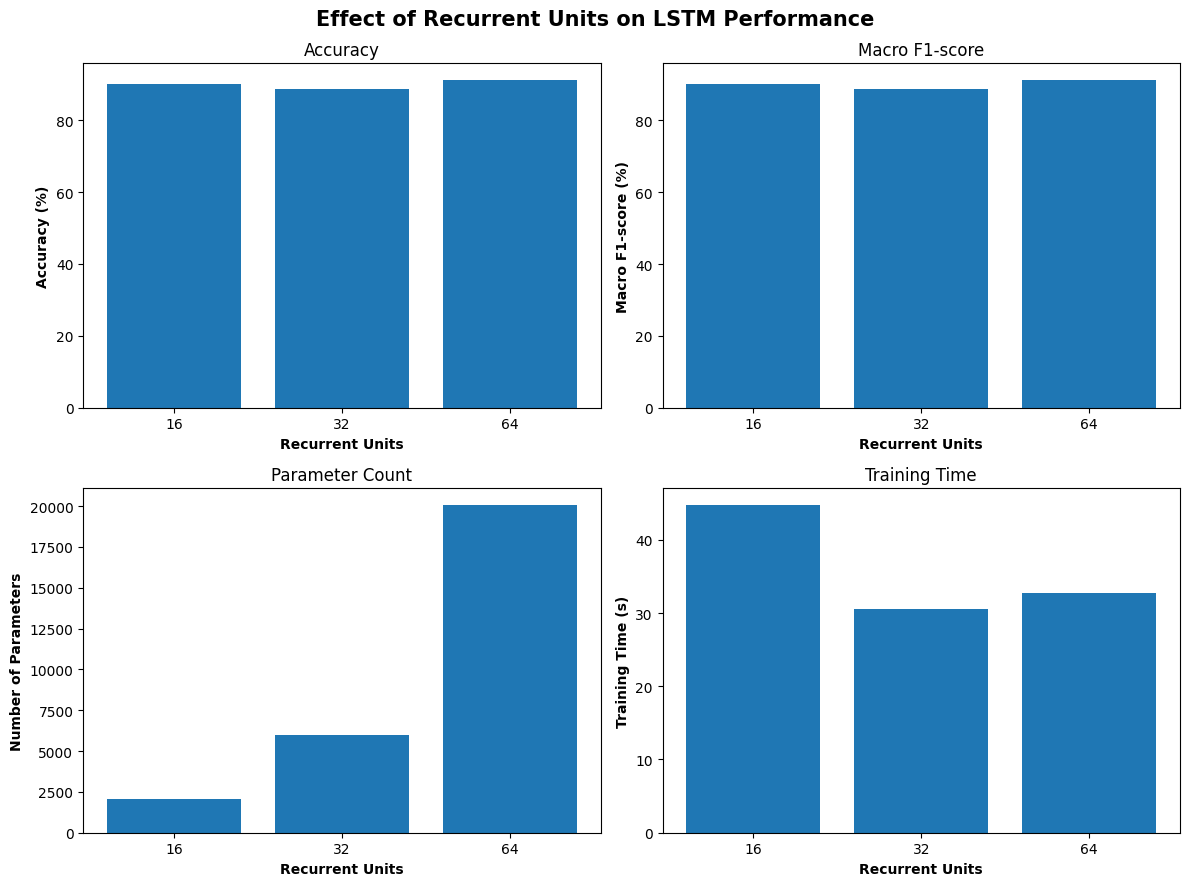

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

units = unit_results_df["Units"].astype(str)

axes[0,0].bar(units, unit_results_df["Accuracy"]*100)
axes[0,0].set_xlabel("Recurrent Units",fontweight="bold")
axes[0,0].set_ylabel("Accuracy (%)",fontweight="bold")
axes[0,0].set_title("Accuracy")

axes[0,1].bar(units, unit_results_df["Macro F1"]*100)
axes[0,1].set_xlabel("Recurrent Units",fontweight="bold")
axes[0,1].set_ylabel("Macro F1-score (%)",fontweight="bold")
axes[0,1].set_title("Macro F1-score")

axes[1,0].bar(units, unit_results_df["Parameters"])
axes[1,0].set_xlabel("Recurrent Units",fontweight="bold")
axes[1,0].set_ylabel("Number of Parameters",fontweight="bold")
axes[1,0].set_title("Parameter Count")

axes[1,1].bar(units, unit_results_df["Training Time (s)"])
axes[1,1].set_xlabel("Recurrent Units",fontweight="bold")
axes[1,1].set_ylabel("Training Time (s)",fontweight="bold")
axes[1,1].set_title("Training Time")

fig.suptitle("Effect of Recurrent Units on LSTM Performance",fontsize=15,fontweight="bold")
plt.tight_layout()
plt.savefig("figures/ex1_units_comparison.png",dpi=300,bbox_inches="tight")
plt.show()

In [71]:
import time
from sklearn.metrics import accuracy_score,f1_score

results = []

for name,layer in [("LSTM",layers.LSTM),("GRU",layers.GRU)]:
    model = keras.Sequential([
        keras.Input(shape=(128,9)),
        layer(32),
        layers.Dropout(0.2),
        layers.Dense(16,activation="relu"),
        layers.Dense(6,activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    start = time.time()

    model.fit(
        X_train,y_train_enc,
        validation_data=(X_val,y_val_enc),
        epochs=30,
        batch_size=32,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=3,
                restore_best_weights=True
            )
        ],
        verbose=0
    )

    train_time = time.time()-start

    pred = np.argmax(model.predict(X_test,verbose=0),axis=1)

    results.append([
        name,
        accuracy_score(y_test_enc,pred),
        f1_score(y_test_enc,pred,average="macro"),
        model.count_params(),
        train_time
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Macro F1","Parameters","Training Time (s)"]
)

results_df

,Model,Accuracy,Macro F1,Parameters,Training Time (s)
0,LSTM,0.885986,0.887681,6006,38.665010
1,GRU,0.880556,0.880301,4758,30.743443


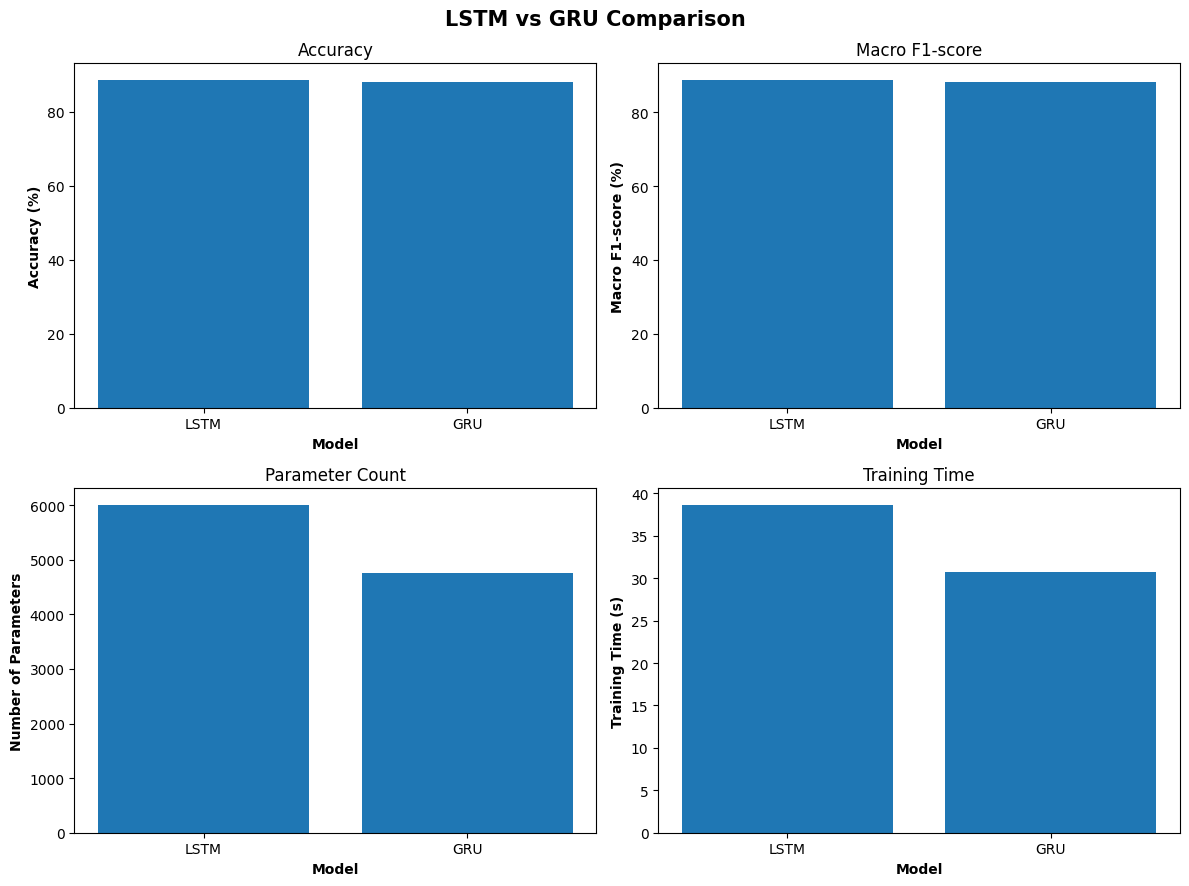

In [72]:
#2
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

models = results_df["Model"]

axes[0,0].bar(models, results_df["Accuracy"]*100)
axes[0,0].set_xlabel("Model",fontweight="bold")
axes[0,0].set_ylabel("Accuracy (%)",fontweight="bold")
axes[0,0].set_title("Accuracy")

axes[0,1].bar(models, results_df["Macro F1"]*100)
axes[0,1].set_xlabel("Model",fontweight="bold")
axes[0,1].set_ylabel("Macro F1-score (%)",fontweight="bold")
axes[0,1].set_title("Macro F1-score")

axes[1,0].bar(models, results_df["Parameters"])
axes[1,0].set_xlabel("Model",fontweight="bold")
axes[1,0].set_ylabel("Number of Parameters",fontweight="bold")
axes[1,0].set_title("Parameter Count")

axes[1,1].bar(models, results_df["Training Time (s)"])
axes[1,1].set_xlabel("Model",fontweight="bold")
axes[1,1].set_ylabel("Training Time (s)",fontweight="bold")
axes[1,1].set_title("Training Time")

fig.suptitle("LSTM vs GRU Comparison",fontsize=15,fontweight="bold")
plt.tight_layout()
plt.savefig("figures/ex2_lstm_vs_gru.png",dpi=300,bbox_inches="tight")
plt.show()

In [73]:
#3
import time
from sklearn.metrics import accuracy_score,f1_score

model_2rnn = keras.Sequential([
    keras.Input(shape=(128,9)),
    layers.LSTM(32,return_sequences=True),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(16,activation="relu"),
    layers.Dense(6,activation="softmax")
])

model_2rnn.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

start = time.time()

history_2rnn = model_2rnn.fit(
    X_train,y_train_enc,
    validation_data=(X_val,y_val_enc),
    epochs=30,
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        )
    ],
    verbose=1
)

train_time_2rnn = time.time()-start

pred_2rnn = np.argmax(model_2rnn.predict(X_test,verbose=0),axis=1)

print("Accuracy:",accuracy_score(y_test_enc,pred_2rnn))
print("Macro F1:",f1_score(y_test_enc,pred_2rnn,average="macro"))
print("Parameters:",model_2rnn.count_params())
print("Training Time (s):",train_time_2rnn)

Epoch 1/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.4818 - loss: 1.2207 - val_accuracy: 0.5515 - val_loss: 1.0099
Epoch 2/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6137 - loss: 0.8364 - val_accuracy: 0.6263 - val_loss: 0.7440
Epoch 3/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6832 - loss: 0.6926 - val_accuracy: 0.7576 - val_loss: 0.6040
Epoch 4/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7093 - loss: 0.6346 - val_accuracy: 0.6545 - val_loss: 0.6605
Epoch 5/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8007 - loss: 0.4728 - val_accuracy: 0.8222 - val_loss: 0.4243
Epoch 6/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8607 - loss: 0.3609 - val_accuracy: 0.8707 - val_loss: 0.3612
Epoch 7/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8706 - loss: 0.3319 - val_accuracy: 0.9111 - val_loss: 0.2602
Epoch 8/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9142 - loss: 0.2375 - val_accu

In [74]:
#4
import time
from sklearn.metrics import accuracy_score,f1_score

bi_results = []

for name,layer in [
    ("LSTM",layers.LSTM(32)),
    ("Bidirectional LSTM",layers.Bidirectional(layers.LSTM(32)))
]:
    model = keras.Sequential([
        keras.Input(shape=(128,9)),
        layer,
        layers.Dropout(0.2),
        layers.Dense(16,activation="relu"),
        layers.Dense(6,activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    start = time.time()

    model.fit(
        X_train,y_train_enc,
        validation_data=(X_val,y_val_enc),
        epochs=30,
        batch_size=32,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=3,
                restore_best_weights=True
            )
        ],
        verbose=0
    )

    train_time = time.time()-start
    pred = np.argmax(model.predict(X_test,verbose=0),axis=1)

    bi_results.append([
        name,
        accuracy_score(y_test_enc,pred),
        f1_score(y_test_enc,pred,average="macro"),
        model.count_params(),
        train_time
    ])

bi_results_df = pd.DataFrame(
    bi_results,
    columns=["Model","Accuracy","Macro F1","Parameters","Training Time (s)"]
)

bi_results_df

,Model,Accuracy,Macro F1,Parameters,Training Time (s)
0,LSTM,0.904649,0.905875,6006,46.181288
1,Bidirectional LSTM,0.877503,0.876433,11894,44.154193


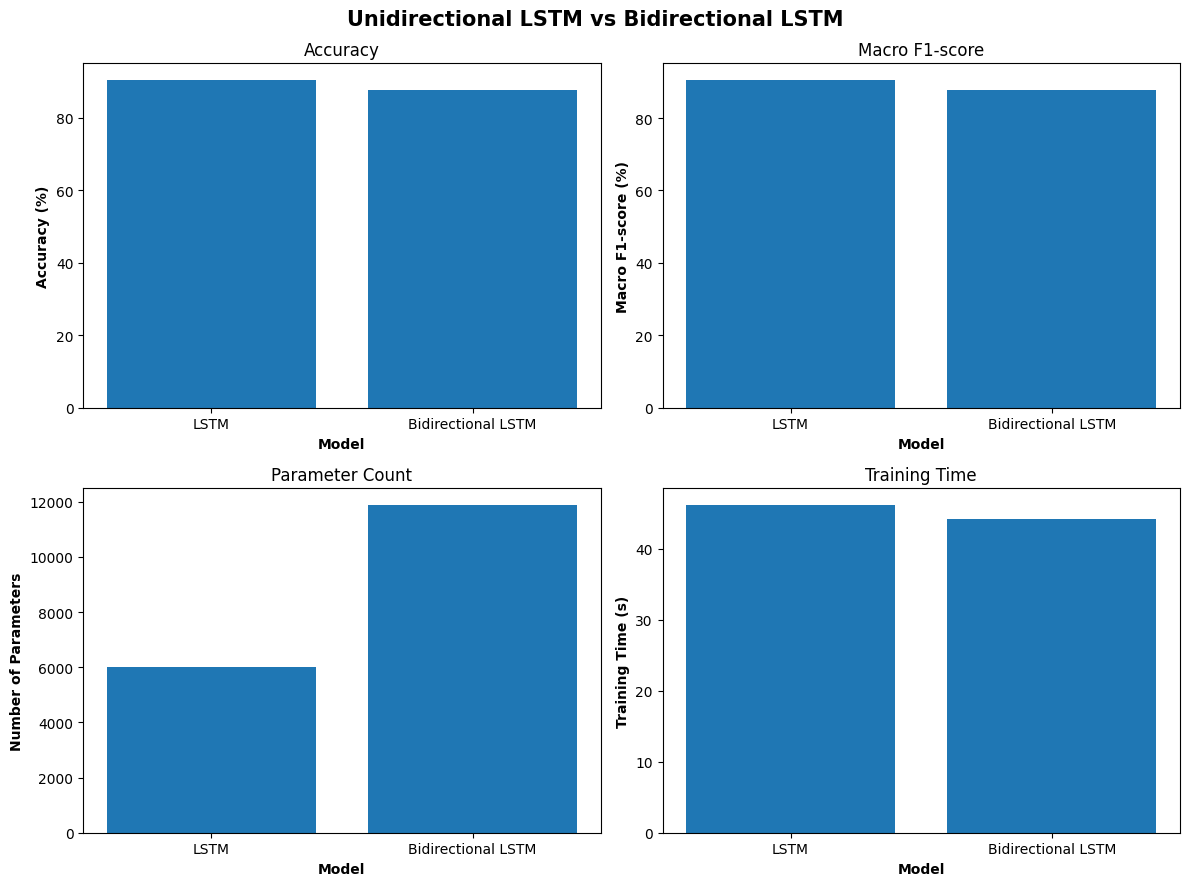

In [77]:
fig,axes = plt.subplots(2,2,figsize=(12,9))

models = bi_results_df["Model"]

axes[0,0].bar(models,bi_results_df["Accuracy"]*100)
axes[0,0].set_xlabel("Model",fontweight="bold")
axes[0,0].set_ylabel("Accuracy (%)",fontweight="bold")
axes[0,0].set_title("Accuracy")

axes[0,1].bar(models,bi_results_df["Macro F1"]*100)
axes[0,1].set_xlabel("Model",fontweight="bold")
axes[0,1].set_ylabel("Macro F1-score (%)",fontweight="bold")
axes[0,1].set_title("Macro F1-score")

axes[1,0].bar(models,bi_results_df["Parameters"])
axes[1,0].set_xlabel("Model",fontweight="bold")
axes[1,0].set_ylabel("Number of Parameters",fontweight="bold")
axes[1,0].set_title("Parameter Count")

axes[1,1].bar(models,bi_results_df["Training Time (s)"])
axes[1,1].set_xlabel("Model",fontweight="bold")
axes[1,1].set_ylabel("Training Time (s)",fontweight="bold")
axes[1,1].set_title("Training Time")

fig.suptitle("Unidirectional LSTM vs Bidirectional LSTM",fontsize=15,fontweight="bold")
plt.tight_layout()
plt.savefig("figures/ex4_bidirectional_lstm.png",dpi=300,bbox_inches="tight")
plt.show()

In [75]:
#5
import time
from sklearn.metrics import f1_score

seq_results = []

for T in [32,64,128]:
    model = keras.Sequential([
        keras.Input(shape=(T,9)),
        layers.LSTM(32),
        layers.Dropout(0.2),
        layers.Dense(16,activation="relu"),
        layers.Dense(6,activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    start = time.time()

    model.fit(
        X_train[:,:T,:],y_train_enc,
        validation_data=(X_val[:,:T,:],y_val_enc),
        epochs=30,
        batch_size=32,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=3,
                restore_best_weights=True
            )
        ],
        verbose=0
    )

    train_time = time.time()-start

    pred = np.argmax(
        model.predict(X_test[:,:T,:],verbose=0),
        axis=1
    )

    seq_results.append([
        T,
        f1_score(y_test_enc,pred,average="macro"),
        model.count_params(),
        train_time
    ])

seq_results_df = pd.DataFrame(
    seq_results,
    columns=["Sequence Length","Macro F1","Parameters","Training Time (s)"]
)

seq_results_df

,Sequence Length,Macro F1,Parameters,Training Time (s)
0,32,0.878511,6006,27.322004
1,64,0.876245,6006,21.935866
2,128,0.887934,6006,41.001486


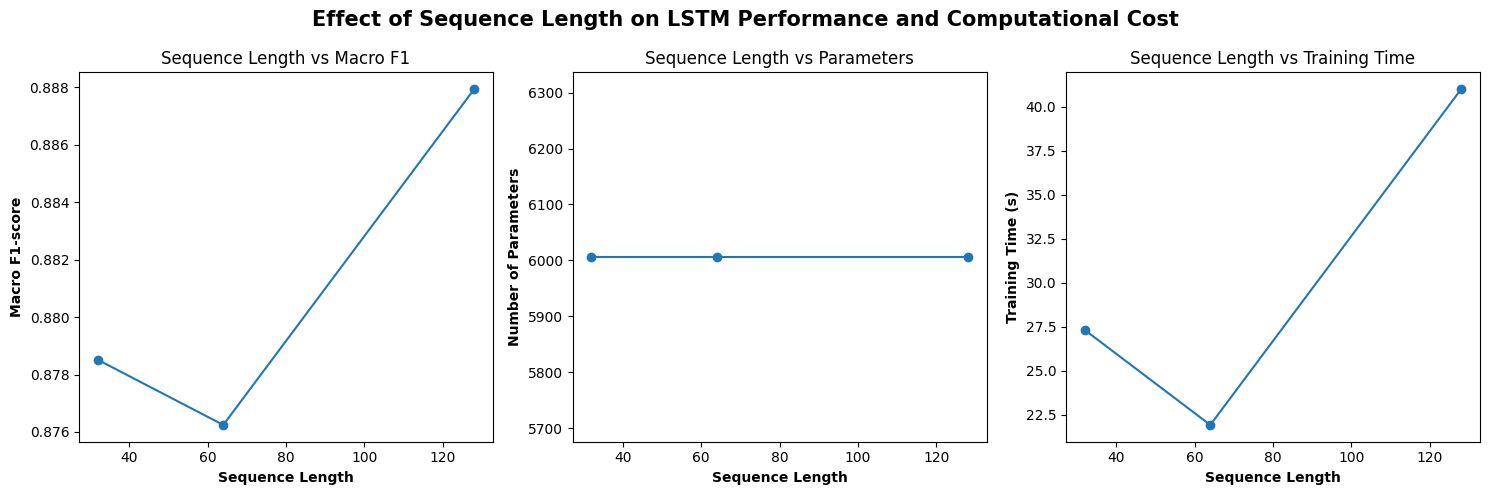

In [76]:
fig,axes = plt.subplots(1,3,figsize=(15,5))

axes[0].plot(
    seq_results_df["Sequence Length"],
    seq_results_df["Macro F1"],
    marker="o"
)
axes[0].set_xlabel("Sequence Length",fontweight="bold")
axes[0].set_ylabel("Macro F1-score",fontweight="bold")
axes[0].set_title("Sequence Length vs Macro F1")

axes[1].plot(
    seq_results_df["Sequence Length"],
    seq_results_df["Parameters"],
    marker="o"
)
axes[1].set_xlabel("Sequence Length",fontweight="bold")
axes[1].set_ylabel("Number of Parameters",fontweight="bold")
axes[1].set_title("Sequence Length vs Parameters")

axes[2].plot(
    seq_results_df["Sequence Length"],
    seq_results_df["Training Time (s)"],
    marker="o"
)
axes[2].set_xlabel("Sequence Length",fontweight="bold")
axes[2].set_ylabel("Training Time (s)",fontweight="bold")
axes[2].set_title("Sequence Length vs Training Time")

fig.suptitle(
    "Effect of Sequence Length on LSTM Performance and Computational Cost",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig(
    "figures/ex5_sequence_length.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [78]:
#6
import time
from sklearn.metrics import accuracy_score,f1_score

video_results = []

for name,layer in [("LSTM",layers.LSTM),("GRU",layers.GRU)]:
    model = keras.Sequential([
        keras.Input(shape=(N_FRAMES,FEATURE_DIM)),
        layer(32),
        layers.Dropout(0.3),
        layers.Dense(len(ACTION_CLASSES),activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    start = time.time()

    model.fit(
        Xv_train,yv_train,
        validation_data=(Xv_val,yv_val),
        epochs=40,
        batch_size=8,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=5,
                restore_best_weights=True
            )
        ],
        verbose=0
    )

    train_time = time.time()-start
    pred = np.argmax(model.predict(Xv_test,verbose=0),axis=1)

    video_results.append([
        name,
        accuracy_score(yv_test,pred),
        f1_score(yv_test,pred,average="macro"),
        model.count_params(),
        train_time
    ])

video_results_df = pd.DataFrame(
    video_results,
    columns=["Model","Accuracy","Macro F1","Parameters","Training Time (s)"]
)

video_results_df

,Model,Accuracy,Macro F1,Parameters,Training Time (s)
0,LSTM,0.947368,0.942857,168229,4.759164
1,GRU,1.000000,1.000000,126309,6.234521


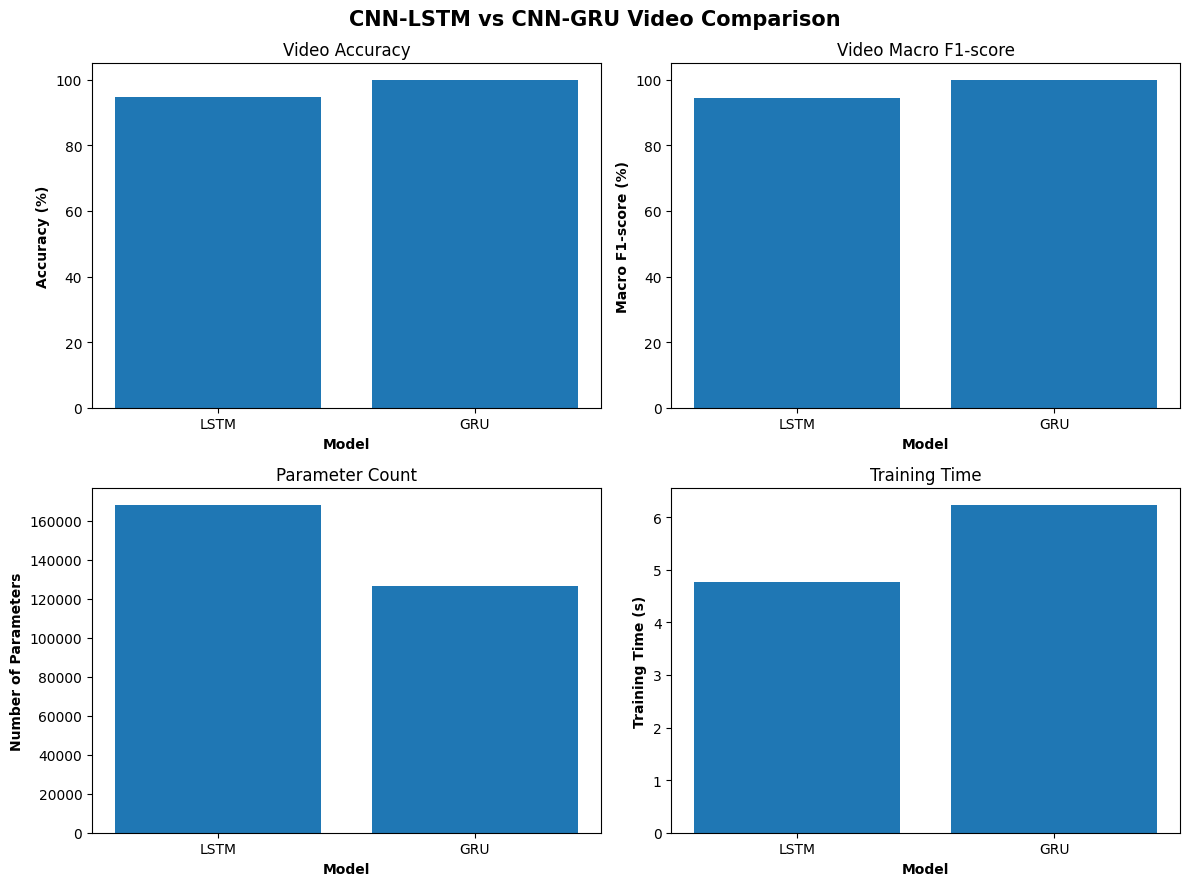

In [79]:
fig,axes = plt.subplots(2,2,figsize=(12,9))

models = video_results_df["Model"]

axes[0,0].bar(models,video_results_df["Accuracy"]*100)
axes[0,0].set_xlabel("Model",fontweight="bold")
axes[0,0].set_ylabel("Accuracy (%)",fontweight="bold")
axes[0,0].set_title("Video Accuracy")

axes[0,1].bar(models,video_results_df["Macro F1"]*100)
axes[0,1].set_xlabel("Model",fontweight="bold")
axes[0,1].set_ylabel("Macro F1-score (%)",fontweight="bold")
axes[0,1].set_title("Video Macro F1-score")

axes[1,0].bar(models,video_results_df["Parameters"])
axes[1,0].set_xlabel("Model",fontweight="bold")
axes[1,0].set_ylabel("Number of Parameters",fontweight="bold")
axes[1,0].set_title("Parameter Count")

axes[1,1].bar(models,video_results_df["Training Time (s)"])
axes[1,1].set_xlabel("Model",fontweight="bold")
axes[1,1].set_ylabel("Training Time (s)",fontweight="bold")
axes[1,1].set_title("Training Time")

fig.suptitle(
    "CNN-LSTM vs CNN-GRU Video Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("figures/ex6_video_lstm_vs_gru.png",dpi=300,bbox_inches="tight")
plt.show()

In [80]:
#7
SEQ_IN = 4
SEQ_OUT = 3
N_S2S = 5000
VOCAB_SIZE = 10

X_s2s = np.random.randint(
    1,VOCAB_SIZE,
    size=(N_S2S,SEQ_IN)
)

Y_s2s = X_s2s[:,::-1][:,:SEQ_OUT]

Xtr_s2s,Xte_s2s,Ytr_s2s,Yte_s2s = train_test_split(
    X_s2s,Y_s2s,
    test_size=0.2,
    random_state=SEED
)

dec_in_tr = np.zeros_like(Ytr_s2s)
dec_in_te = np.zeros_like(Yte_s2s)

dec_in_tr[:,1:] = Ytr_s2s[:,:-1]
dec_in_te[:,1:] = Yte_s2s[:,:-1]

print("Input shape:",Xtr_s2s.shape)
print("Output shape:",Ytr_s2s.shape)

Input shape: (4000, 4)
Output shape: (4000, 3)


In [81]:
latent_dim = 64

enc_in = tf.keras.Input(shape=(SEQ_IN,))
enc_emb = tf.keras.layers.Embedding(VOCAB_SIZE,latent_dim)(enc_in)

_,enc_h,enc_c = tf.keras.layers.LSTM(
    latent_dim,
    return_state=True
)(enc_emb)

dec_in = tf.keras.Input(shape=(SEQ_OUT,))
dec_emb = tf.keras.layers.Embedding(
    VOCAB_SIZE,
    latent_dim
)(dec_in)

dec_out = tf.keras.layers.LSTM(
    latent_dim,
    return_sequences=True
)(
    dec_emb,
    initial_state=[enc_h,enc_c]
)

dec_out = tf.keras.layers.Dense(
    VOCAB_SIZE,
    activation="softmax"
)(dec_out)

seq2seq_ex7 = tf.keras.Model(
    [enc_in,dec_in],
    dec_out
)

seq2seq_ex7.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

seq2seq_ex7.summary()

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_37      │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_38      │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 4, 64)     │        640 │ input_layer_37[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 3, 64)     │        640 │ input_layer_38[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_25 (LSTM)      │ [(None, 64),      │     33,024 │ embedding_4[0][0] │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_26 (LSTM)      │ (None, 3, 64)     │     33,024 │ embedding_5[0][0… │
│                     │                   │            │ lstm_25[0][1],    │
│                     │                   │            │ lstm_25[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_64 (Dense)    │ (None, 3, 10)     │        650 │ lstm_26[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 67,978 (265.54 KB)

 Trainable params: 67,978 (265.54 KB)

 Non-trainable params: 0 (0.00 B)

In [82]:
history_ex7 = seq2seq_ex7.fit(
    [Xtr_s2s,dec_in_tr],
    Ytr_s2s,
    validation_data=(
        [Xte_s2s,dec_in_te],
        Yte_s2s
    ),
    epochs=40,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=6,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.3505 - loss: 1.9798 - val_accuracy: 0.4377 - val_loss: 1.4604
Epoch 2/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5527 - loss: 1.1461 - val_accuracy: 0.7627 - val_loss: 0.7467
Epoch 3/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9231 - loss: 0.4253 - val_accuracy: 0.9890 - val_loss: 0.2047
Epoch 4/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9976 - loss: 0.1307 - val_accuracy: 0.9990 - val_loss: 0.0853
Epoch 5/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9995 - loss: 0.0629 - val_accuracy: 1.0000 - val_loss: 0.0496
Epoch 6/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9998 - loss: 0.0384 - val_accuracy: 1.0000 - val_loss: 0.0324
Epoch 7/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9999 - loss: 0.0261 - val_accuracy: 1.0000 - val_loss: 0.0233
Epoch 8/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 0.0192 - val_accuracy: 1.0000 - val_loss

In [84]:
pred_ex7 = seq2seq_ex7.predict(
    [Xte_s2s,dec_in_te],
    batch_size=128,
    verbose=0
)

pred_ex7 = np.argmax(pred_ex7,axis=-1)

token_acc_ex7 = (pred_ex7 == Yte_s2s).mean()
sequence_acc_ex7 = (pred_ex7 == Yte_s2s).all(axis=1).mean()

print(f"Token accuracy    : {token_acc_ex7*100:.2f}%")
print(f"Sequence accuracy : {sequence_acc_ex7*100:.2f}%")
print(f"Training loss     : {history_ex7.history['loss'][-1]:.4f}")
print(f"Validation loss   : {history_ex7.history['val_loss'][-1]:.4f}")

Token accuracy    : 100.00%
Sequence accuracy : 100.00%
Training loss     : 0.0007
Validation loss   : 0.0007


In [85]:
print("=== Input Sequence -> Predicted Output ===")

for i in range(5):
    print(
        f"Input: {list(Xte_s2s[i])} -> "
        f"Predicted: {list(pred_ex7[i])} -> "
        f"True: {list(Yte_s2s[i])}"
    )

=== Input Sequence -> Predicted Output ===
Input: [np.int64(8), np.int64(7), np.int64(7), np.int64(6)] -> Predicted: [np.int64(6), np.int64(7), np.int64(7)] -> True: [np.int64(6), np.int64(7), np.int64(7)]
Input: [np.int64(3), np.int64(8), np.int64(8), np.int64(6)] -> Predicted: [np.int64(6), np.int64(8), np.int64(8)] -> True: [np.int64(6), np.int64(8), np.int64(8)]
Input: [np.int64(8), np.int64(9), np.int64(3), np.int64(6)] -> Predicted: [np.int64(6), np.int64(3), np.int64(9)] -> True: [np.int64(6), np.int64(3), np.int64(9)]
Input: [np.int64(1), np.int64(8), np.int64(8), np.int64(2)] -> Predicted: [np.int64(2), np.int64(8), np.int64(8)] -> True: [np.int64(2), np.int64(8), np.int64(8)]
Input: [np.int64(4), np.int64(6), np.int64(3), np.int64(5)] -> Predicted: [np.int64(5), np.int64(3), np.int64(6)] -> True: [np.int64(5), np.int64(3), np.int64(6)]


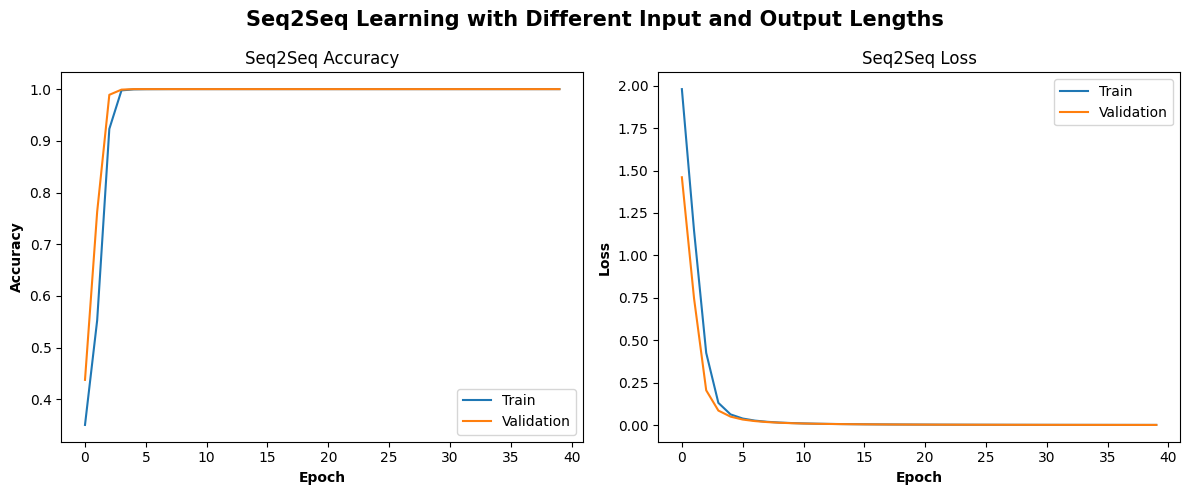

In [86]:
fig,axes = plt.subplots(1,2,figsize=(12,5))

axes[0].plot(history_ex7.history["accuracy"],label="Train")
axes[0].plot(history_ex7.history["val_accuracy"],label="Validation")
axes[0].set_xlabel("Epoch",fontweight="bold")
axes[0].set_ylabel("Accuracy",fontweight="bold")
axes[0].set_title("Seq2Seq Accuracy")
axes[0].legend()

axes[1].plot(history_ex7.history["loss"],label="Train")
axes[1].plot(history_ex7.history["val_loss"],label="Validation")
axes[1].set_xlabel("Epoch",fontweight="bold")
axes[1].set_ylabel("Loss",fontweight="bold")
axes[1].set_title("Seq2Seq Loss")
axes[1].legend()

fig.suptitle(
    "Seq2Seq Learning with Different Input and Output Lengths",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig(
    "figures/ex7_different_sequence_lengths.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 15. Zip Figures and Tables for Download
Run this cell to package every 600 DPI figure and CSV table into a single archive for your LaTeX report.

In [45]:
import shutil

# Package figures + CSV result tables into report assets.
REPORT_ASSETS_DIR = os.path.join(BASE_DIR, "report_assets")
os.makedirs(REPORT_ASSETS_DIR, exist_ok=True)

for f in os.listdir(FIG_DIR):
    src_file = os.path.join(FIG_DIR, f)
    if os.path.isfile(src_file):
        shutil.copy(src_file, REPORT_ASSETS_DIR)

for f in [
    "table_rnn_lstm_gru_metrics.csv",
    "table_sequence_length_f1.csv",
    "table_consolidated_results.csv",
    "table_seq2seq_results.csv",
    "table_seq2seq_samples.csv"
]:
    src_file = os.path.join(BASE_DIR, f)
    if os.path.exists(src_file):
        shutil.copy(src_file, REPORT_ASSETS_DIR)

archive_base = os.path.join(BASE_DIR, "experiment6_report_assets")
shutil.make_archive(
    archive_base,
    "zip",
    REPORT_ASSETS_DIR
)

print("Archive ready:", archive_base + ".zip")
print(
    "Contains Plot 1-9 PNGs at 600 DPI and all result CSVs."
)


Archive ready: /content/experiment6_report_assets.zip
Contains all Plot 1-9 PNGs (600 DPI) and all result CSVs, ready for \includegraphics / \input in LaTeX.
